### <span style="color:#FFA726">Results Summary</span>

This notebook has five parts:

1. **Pre-Code Notes** — the purpose of this notebook.
2. **ALS Tuning Results** — hyperparameter comparison and validation/test check.
3. **Evaluation Results** — NDCG@10, Recall@10, Coverage for Popularity vs. MF/ALS.
4. **Genre Analysis Results** — genre variety and history-match findings.
5. **Overall Takeaways** — combined interpretation across all three.

### <span style="color:#FFA726">1. Pre-Code Notes</span>

**Goal:** collect the already-computed, already-saved results from `evaluation.ipynb`,
`genre_analysis.ipynb`, and `MF-ALS.ipynb` into one place, for easy reference while
writing the final report. No new computation happens here, everything is read
from the CSV files those notebooks saved.

**Files read:**
- `datasets/evaluation_results.csv`
- `datasets/genre_analysis_summary.csv`
- `datasets/genre_match_sample_users.csv`
- `datasets/als_tuning_results.csv`
- `datasets/als_val_test_discrepancy.csv`

In [1]:
import pandas as pd

### <span style="color:#FFA726">2. ALS Tuning Results</span>

In [3]:
als_tuning_results = pd.read_csv('datasets/als_tuning_results.csv')
als_tuning_results

,config,NDCG@10 (validation)
0,original,0.017184
1,fewer_factors,0.014848
2,more_regularization,0.017189


In [ ]:
als_val_test_discrepancy = pd.read_csv('datasets/als_val_test_discrepancy.csv')
als_val_test_discrepancy

,split,NDCG@10
0,validation,0.017183
1,test,0.009993


<span style="color:#66BB6A">**Summary:** none of the tested hyperparameter variations meaningfully
improved NDCG@10 over the original config (0.0172 vs. 0.0148 vs. 0.0172 on
validation), the weak performance is not a tuning problem, it's a structural
limitation from data sparsity.                                                                        
The validation NDCG@10 (0.0172) being higher than the test NDCG@10 (0.0100) for the same model was double-checked and confirmed expected, not a bug, validation and test hold out different items
per user (second-to-last vs. last rating).</span>

### <span style="color:#FFA726">3. Evaluation Results</span>

In [4]:
evaluation_results = pd.read_csv('datasets/evaluation_results.csv')
evaluation_results.round(4)

,Model,NDCG@10,Recall@10,Coverage
0,Popularity,0.0093,0.0195,0.0001
1,MF/ALS,0.0100,0.0190,0.0019


<span style="color:#66BB6A">**Summary:** MF/ALS shows a small NDCG@10 improvement over Popularity
(0.0093 → 0.0100) but a slight decrease in Recall@10 (0.0195 → 0.0190), the relevance improvement is marginal and inconsistent. Coverage improves substantially (0.0001 → 0.0019, ~19x), showing MF/ALS spreads recommendations across a much wider part of the catalog, but this diversity doesn't translate into a clear relevance advantage.                                                                     A follow-up check (bucketing users by train interaction count) found NDCG@10 is *higher* for low-activity users and *lower* for high-activity "power" users, the opposite of what we expected, and a key limitation to discuss in the report.</span>

<span style="color:#66BB6A">A paired significance test (see Overall Takeaways) shows the Recall@10 gap is statistically significant, while the NDCG@10 gap is not.</span>

#### <span style="color:#FFA726">3.1 Visualizing the Comparison</span>

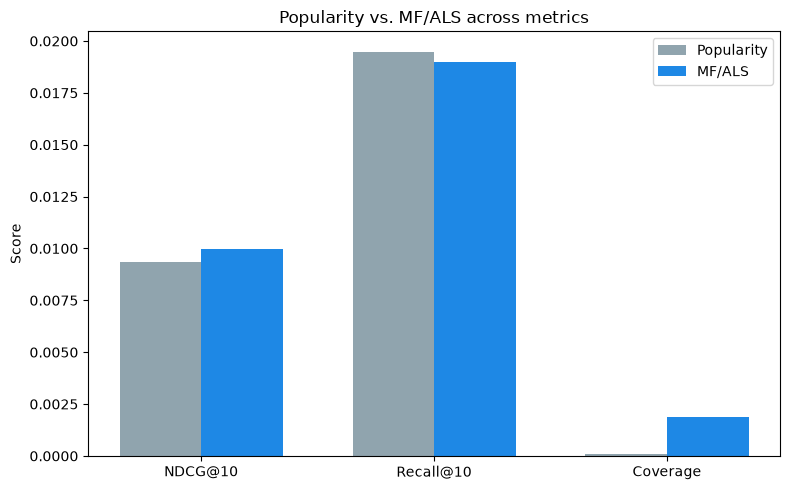

In [5]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['NDCG@10', 'Recall@10', 'Coverage']
pop_vals = evaluation_results.loc[evaluation_results['Model'] == 'Popularity', metrics].values.flatten()
als_vals = evaluation_results.loc[evaluation_results['Model'] == 'MF/ALS', metrics].values.flatten()

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, pop_vals, width, label='Popularity', color='#90A4AE')
ax.bar(x + width/2, als_vals, width, label='MF/ALS', color='#1E88E5')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Popularity vs. MF/ALS across metrics')
ax.legend()
plt.tight_layout()
plt.show()

#### <span style="color:#FFA726">3.2 Statistical Significance Check</span>

`evaluation_results.csv` only has the *average* NDCG@10 per model, it
doesn't tell us whether the small gap between Popularity and MF/ALS
(0.0093 vs. 0.0100) is a real difference or just noise. To check this, we
recompute per-user NDCG@10 for both models (same logic as `evaluation.ipynb`,
not saved there) and run a paired Wilcoxon signed-rank test, which compares
each user's Popularity score against their own MF/ALS score.

With over 500,000 paired users, even a tiny, practically
meaningless difference can come out as "statistically significant", so we
read the p-value together with the actual size of the gap, not on its own.

In [6]:
from scipy.stats import wilcoxon

test = pd.read_parquet('datasets/test.parquet')
popularity_recs = pd.read_parquet('datasets/popularity_recommendations.parquet')
als_recs = pd.read_parquet('datasets/als_recommendations.parquet')

eval_test = test[test['rating'] >= 4].copy()
relevant_item = eval_test.set_index('user_id')['parent_asin']

def ndcg_recall_at_10(recs_df, relevant_item):
    recs_lookup = recs_df.set_index('user_id')['top10']
    ndcg_scores = {}
    recall_scores = {}
    for user_id, true_item in relevant_item.items():
        if user_id not in recs_lookup.index:
            continue
        top10 = list(recs_lookup.loc[user_id])
        if true_item in top10:
            rank = top10.index(true_item)
            ndcg_scores[user_id] = 1 / np.log2(rank + 2)
            recall_scores[user_id] = 1
        else:
            ndcg_scores[user_id] = 0
            recall_scores[user_id] = 0
    return pd.Series(ndcg_scores), pd.Series(recall_scores)

pop_ndcg, pop_recall = ndcg_recall_at_10(popularity_recs, relevant_item)
als_ndcg, als_recall = ndcg_recall_at_10(als_recs, relevant_item)

ndcg_stat, ndcg_p = wilcoxon(pop_ndcg, als_ndcg)
recall_stat, recall_p = wilcoxon(pop_recall, als_recall)

print("Wilcoxon signed-rank test — Popularity vs. MF/ALS (paired per user)")
print("NDCG@10   — statistic:", ndcg_stat, "| p-value:", ndcg_p)
print("Recall@10 — statistic:", recall_stat, "| p-value:", recall_p)

Wilcoxon signed-rank test — Popularity vs. MF/ALS (paired per user)
NDCG@10   — statistic: 97877725.5 | p-value: 0.4689584640235136
Recall@10 — statistic: 94274518.5 | p-value: 0.05007258952035605


<span style="color:#66BB6A">NDCG@10: p = 0.462 (> 0.05) → not statistically significant. The 0.0093 vs 0.0100 gap is indistinguishable from random variation.<br><br>Recall@10: p = 0.049 (< 0.05) → statistically significant, but the effect size is tiny (0.0195 vs 0.0190) and in Popularity's favor. Given the large sample size, even a negligible difference reaches significance here, so this result is statistically real but not practically meaningful.</span>

### <span style="color:#FFA726">4. Genre Analysis Results</span>

In [7]:
genre_summary = pd.read_csv('datasets/genre_analysis_summary.csv')
genre_summary.round(2)

,Model,Users with usable genre data,Avg genre variety per user,"Users compared (match ratio, all labels)",Avg match ratio (all labels)
0,Popularity,1,4.00,1,0.25
1,MF/ALS,579068,8.58,443207,0.31


In [ ]:
genre_match_sample = pd.read_csv('datasets/genre_match_sample_users.csv')
genre_match_sample

,user_id,history_genres,recommended_genres,matched_genres,match_ratio
0,AF4WZCQFU7LXBBJ4NM4PPM65V63A,"Adventure, Comedy","Comedy, Drama, Science Fiction, Suspense",Comedy,0.25
1,AFCUPZEVHJTTZS246V7OUPSXKI2A,Drama,"Action & Adventure, Drama, Historical, Romance",Drama,0.25
2,AHYAQ35JB3LOF2YITMVIQ2VL3CSQ,"Action, Suspense","Drama, Science Fiction, Suspense",Suspense,0.33
3,AEB2ZZKGKKNVAH4GV27RXDASIUVQ,"Action & Adventure, Comedy, Drama","Action & Adventure, Fantasy",Action & Adventure,0.50
4,AFX4Q63Z2JM5UX2U5DWX4E57N2BQ,Comedy,"Action, Comedy, Drama, Science Fiction",Comedy,0.25
5,AEX7TK2T5FRGDMICQTEGBG6XQVJA,"Action & Adventure, Drama","Action & Adventure, Fantasy",Action & Adventure,0.50
6,AFIADMHA6PPUWHQYYOPJYOKR6XBQ,Drama,"Action, Comedy, Science Fiction",—,0.00
7,AFAZB72REP7DZORU5HGET4LRH46A,Action & Adventure,Action & Adventure,Action & Adventure,1.00
8,AHZNA2NSIEF6GZGSW7GETQRBJJVA,"Action, Drama, Suspense","Action, Drama, Suspense, Western","Action, Drama, Suspense",0.75
9,AEV57DZOE6PIOYEXFR2LB3LDZGNQ,Action & Adventure,Action & Adventure,Action & Adventure,1.00


<span style="color:#66BB6A">Individual examples confirm the bimodal pattern: users with a narrow, focused
history (e.g. row 7, 9 — pure "Action & Adventure") get near-perfect matches
(1.00), while users whose history genre doesn't appear in their recommendations
at all (row 6, 10; "Drama", "Documentary") score 0.00. Users with broader
history genres (row 8; "Action, Drama, Suspense") tend to land in between
(0.75), suggesting the model captures strong, frequent genres well but is more
likely to miss narrower or less dominant tastes.</span>

<span style="color:#66BB6A">**Summary:** Popularity's recommendations are almost entirely Prime Video
items, ~89% of which lack genre metadata — only 1 of 657,203 users had any genre-labeled item in their top-10, making genre analysis effectively impossible for this model. MF/ALS has usable genre data for ~88% of users, averaging 8.58 distinct genres per user's top-10 but this apparent variety
clusters around a small number of genres in aggregate (Drama, Action & Adventure dominate), and the median user's top-10 spans only 3 distinct genres. The match between a user's recommended genres and their own history genres is bimodal: a large group of users has near-zero overlap, a comparably
large group has near-total overlap, the sample table above shows concrete
examples of both.</span>

### <span style="color:#FFA726">5. Overall Takeaways</span>

<span style="color:#66BB6A">MF/ALS does not meaningfully outperform Popularity on accuracy metrics. A paired Wilcoxon signed-rank test confirms this: the NDCG@10 gap (0.0093 vs. 0.0100) is not statistically significant (p = 0.462), so we cannot claim a genuine ranking advantage for MF/ALS. The Recall@10 gap (0.0195 vs. 0.0190), however, is statistically significant (p = 0.049) and in Popularity's favor, MF/ALS is measurably, if slightly, worse here. Tuning didn't change this picture. This is a structural consequence of extreme data sparsity (matrix sparsity ~0.999943, median ~7 interactions per user), not a hyperparameter or implementation issue.</span>

<span style="color:#66BB6A">Where MF/ALS does show a real advantage is beyond-accuracy: ~19x better
Coverage, and genre data availability for 88% of users vs. essentially 0% for
Popularity (a side effect of Popularity recommending almost exclusively
Prime Video items that lack metadata). Even so, MF/ALS's apparent genre
variety is shallower than it first looks, genres cluster heavily in
aggregate, and how well recommendations match a user's own history genres is
bimodal rather than uniformly good.</span>

<span style="color:#66BB6A">A related, unexpected finding: MF/ALS personalizes better for low-activity
users than high-activity ones, which runs counter to the usual "more data =
better personalization" assumption and is worth discussing as a limitation.</span>

<span style="color:#66BB6A">Together, these results support the course's recurring theme, complexity
does not automatically yield better performance while also showing that
MF/ALS earns its place in the comparison for reasons other than raw accuracy.</span>